# Tratamento dos dados

Dado que uma rede MLP espera como entrada um vetor unidimensional de características, é necessário adequar a representação das imagens da base de dados para esse formato.

Para isso, aplicaram-se as seguintes etapas de pré-processamento:

1. Conversão das imagens de RGB para escala de cinza, removendo os canais de cor e mantendo apenas a intensidade dos pixels, o que reduz a dimensionalidade dos dados.

2. *Flatten* das imagens para representação em linha, transformando a matriz bidimensional da imagem em um vetor unidimensional de características.

In [3]:
# Imports

from keras.datasets import cifar10
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense

In [ ]:
# Carregamento dos dados

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print('Train Images Shape:      ', x_train.shape)
print('Train Labels Shape:      ', y_train.shape)

print('\nTest Images Shape:       ', x_test.shape)
print('Test Labels Shape:       ', y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 311s 2us/step
Train Images Shape:       (50000, 32, 32, 3)
Train Labels Shape:       (50000, 1)

Test Images Shape:        (10000, 32, 32, 3)
Test Labels Shape:        (10000, 1)


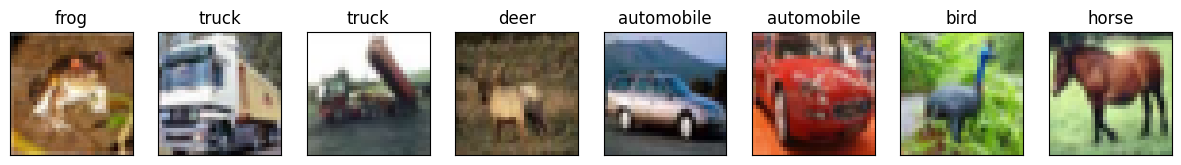

In [ ]:
# Exemplos de imagens

# Classes
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(15,15))

# Loop over the first 25 images
for i in range(8):
    # Create a subplot for each image
    plt.subplot(8, 8, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    # Display the image
    plt.imshow(x_train[i])

    # Set the label as the title
    plt.title(class_names[y_train[i][0]], fontsize=12)

# Display the figure
plt.show()

In [ ]:
# Conversão das imagens de RGB para escala de cinza

# fórmula padrão: Y = 0.299 R + 0.587 G + 0.114 B
x_train_gray = np.dot(x_train[..., :3], [0.299, 0.587, 0.114])
x_test_gray = np.dot(x_test[..., :3], [0.299, 0.587, 0.114])

print('Train Images Shape (Gray scale):      ', x_train_gray.shape)
print('Test Images Shape (Gray scale):       ', x_test_gray.shape)

Train Images Shape (Gray scale):       (50000, 32, 32)
Test Images Shape (Gray scale):        (10000, 32, 32)


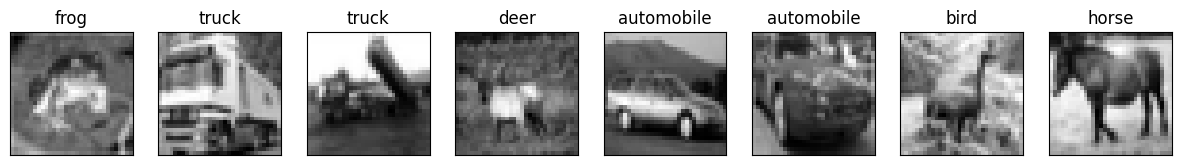

In [ ]:
# Exemplos de imagens

# Classes
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(15,15))

# Loop over the first 25 images
for i in range(8):
    # Create a subplot for each image
    plt.subplot(8, 8, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    # Display the image
    plt.imshow(x_train_gray[i], cmap='gray')

    # Set the label as the title
    plt.title(class_names[y_train[i][0]], fontsize=12)

# Display the figure
plt.show()

In [ ]:
# Flatten das imagens

x_train_df = pd.DataFrame(x_train_gray.reshape(x_train_gray.shape[0], -1))
x_test_df = pd.DataFrame(x_test_gray.reshape(x_test_gray.shape[0], -1))

print('Train Images Shape (Gray scale & Flatten):      ', x_train_df.shape)
print('Test Images Shape (Gray scale & Flatten):       ', x_test_df.shape)

Train Images Shape (Gray scale & Flatten):       (50000, 1024)
Test Images Shape (Gray scale & Flatten):        (10000, 1024)


# Estrutura da rede

Explicar de que artigos tiramos os valores de dropout, nº de camadas, etc.


> Nos testes verificou-se que, adotando-se o número de
neurônios das camadas ocultas como o dobro do número de pixels, obtêm-se o melhor
desempenho. Isso resultaria 392 neurônios, porém, por tentativa, verificou-se que o
uso de 350 neurônios, neste caso, foi a melhor opção.

[Link do Artigo](https://dspace.uniube.br:8443/bitstream/123456789/3092/1/EFICI%c3%8aNCIA%20DE%20REDES%20NEURAIS%20CONVOLUCIONAIS%20NA%20IDENTIFICA%c3%87%c3%83O%20DE%20EDIF%c3%8dCIOS%20EM%20CONDI%c3%87%c3%95ES%20DESAFIADORAS%20DE%20IMAGENS.pdf)


In [5]:
# Construção dos modelos da rede

model_1 = Sequential()

model_1.add(Dense(units=350,activation='sigmoid', input_dim=1024))
## Utilização de seed pra permitir replicabilidade

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Experimento 1 - Sem dropout e sem early stop

In [ ]:
# Treinamento

In [ ]:
# Resultados

# Experimento 2 - Sem dropout e com early stop

In [ ]:
# Treinamento

In [ ]:
# Resutados

# Experimento 3 - Com dropout e sem early stop

In [ ]:
# Treinamento

In [ ]:
# Resultados

# Experimento 4 - Com dropout e com early stop

In [ ]:
# Treinamento

In [ ]:
# Resultados